# **Portfolio:** Mario Casanova — Data Science & Analytics Portfolio
## **Case Study:** Mathematical Modeling & Quantum Mechanics

---
*Note: I built this notebook as a numerical solver for the time-dependent Schrödinger equation via the Crank–Nicolson method, and I use it to produce genuine quantum tunneling: a Gaussian wave packet whose mean energy sits below the barrier height ($E < V_0$) crosses a classically forbidden region anyway. That crossing happens through the recurring inversion of sparse tridiagonal matrices over a discretized spatial grid, and the number I actually care about is the transmitted fraction, read off once the reflected and transmitted lobes have pulled apart.*

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Single source of truth: the Crank-Nicolson solver lives in src/schrodinger.py
# (and is unit-tested there). The notebook imports it so the propagated packet and
# the tests run the exact same numerics.
sys.path.insert(0, str(Path.cwd().parent / "src"))
from schrodinger import (
    build_cn_operators,
    gaussian_wave_packet,
    probability_norm,
    propagate,
    reflection_probability,
    transmission_probability,
)

plt.style.use('dark_background')

# Simplified quantum constants (hbar = 2m = 1, so a plane wave of momentum k has energy E = k^2)
dt = 0.005
time_steps = 100   # read transmission once reflected/transmitted lobes separate, before any grid-edge reflection

### 1. The stage: a spatial grid and a barrier
I load the pre-calculated spatial grid and the barrier profile — the one-dimensional stage on which the wave packet is about to try its luck.

In [2]:
df_pot = pd.read_csv('../data/quantum_barrier_profile.csv')
x = df_pot['x'].values
V = df_pot['V'].values

N = len(x)
dx = x[1] - x[0]

print(f"[*] Mesh discretization: {N} spatial nodes. Differential dx = {dx:.4f}")

[*] Mesh discretization: 1000 spatial nodes. Differential dx = 0.0100


### 2. A wave packet aimed at the wall
I initialize the particle as a probability density carrying momentum ($k_0$) pointed straight at the barrier.

In [ ]:
x0 = -2.0      # Initial position (left of the barrier)
sigma = 0.25   # Spatial width of the packet
k0 = 5.0       # Central momentum  ->  mean energy E = k0**2

# With hbar = 2m = 1, the packet's mean energy is E = k0^2. Genuine tunneling requires E < V0.
E_mean = k0**2
print(f"[*] Packet mean energy E = k0^2 = {E_mean:.0f}   |   barrier V0 = {V.max():.0f}   |   E/V0 = {E_mean/V.max():.2f}")
print("[*] E < V0  ->  the barrier is classically forbidden; any transmission is genuine quantum tunneling.")

# Normalized Gaussian wave packet (probability integral = 1)
psi = gaussian_wave_packet(x, x0, sigma, k0, dx)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, np.abs(psi)**2, color='cyan', label='Initial Density $|\\Psi(x,0)|^2$')
ax.fill_between(x, V / np.max(V) * np.max(np.abs(psi)**2), color='red', alpha=0.3, label='Potential Barrier V(x)')
ax.set_title("Boundary Conditions and Initial Packet", fontsize=14, pad=10)
ax.legend(loc="upper left")
plt.show()

### 3. An implicit scheme that can't blow up
Discretizing the Schrödinger equation
$i\frac{\partial \Psi}{\partial t} = \left(-\frac{\partial^2}{\partial x^2} + V(x)\right)\Psi$

gives the operator of the Hamiltonian system $(H)$. Working from that operator, Crank–Nicolson is unconditionally stable, which I get here by isolating the future time step $\Psi^{n+1}$:
$\left(I + \frac{i \Delta t}{2} H \right) \Psi^{n+1} = \left(I - \frac{i \Delta t}{2} H \right) \Psi^{n}$

In [ ]:
# Crank-Nicolson operators for the discretized Hamiltonian (built in src/schrodinger.py):
#   (I + i dt/2 H) psi^{n+1} = (I - i dt/2 H) psi^{n}
solver, M_R = build_cn_operators(x, V, dt)
print("[*] Factorized Vector Matrix. Direct linear solver initialized.")

### 4. Stepping forward, then asking how much got through
I advance the solution step by step, solving $M_L\,\Psi^{n+1} = M_R\,\Psi^{n}$. The packet's mean energy ($E = k_0^2 = 25$) sits below the barrier height ($V_0 = 50$), so classically nothing should cross — the region under the barrier is forbidden territory. Whatever fraction shows up on the far side anyway is the quantum tunneling probability, and I read it off once the reflected and transmitted lobes have pulled apart, before either one reaches the edge of the grid.

In [ ]:
SNAP_EVERY = 20

# Crank-Nicolson propagation: solve M_L psi^{n+1} = M_R psi^n each step.
psi, density_history = propagate(psi, solver, M_R, time_steps, SNAP_EVERY)

# Total probability must remain 1 (the scheme is exactly unitary)
total_prob = probability_norm(psi, dx)

# Transmission (beyond the barrier, x > 1.0) and reflection (before it, x < 0.5)
trans_prob = transmission_probability(psi, x, dx, x_min=1.0)
refl_prob = reflection_probability(psi, x, dx, x_max=0.5)

print(f"[+] Norm conservation (should be 1): {total_prob:.4f}")
print(f"[+] Tunneling (transmission) probability T: {trans_prob*100:.2f} %")
print(f"[+] Reflection probability R:              {refl_prob*100:.2f} %   (E < V0, so most of the packet reflects)")

### Final Visualization
The frames below show the packet meeting the barrier and splitting: a large lobe reflects, a small one transmits. Classical mechanics has no explanation for that second lobe (the packet's energy never clears the barrier), and yet there it is on the far side, the leaked fraction of a wave that was never supposed to arrive. Underneath that display, the unitary Crank–Nicolson scheme keeps the total probability at exactly 1 throughout, which is the only honesty check a solver like this owes you: whatever slips through the wall came from somewhere, not from a rounding error.

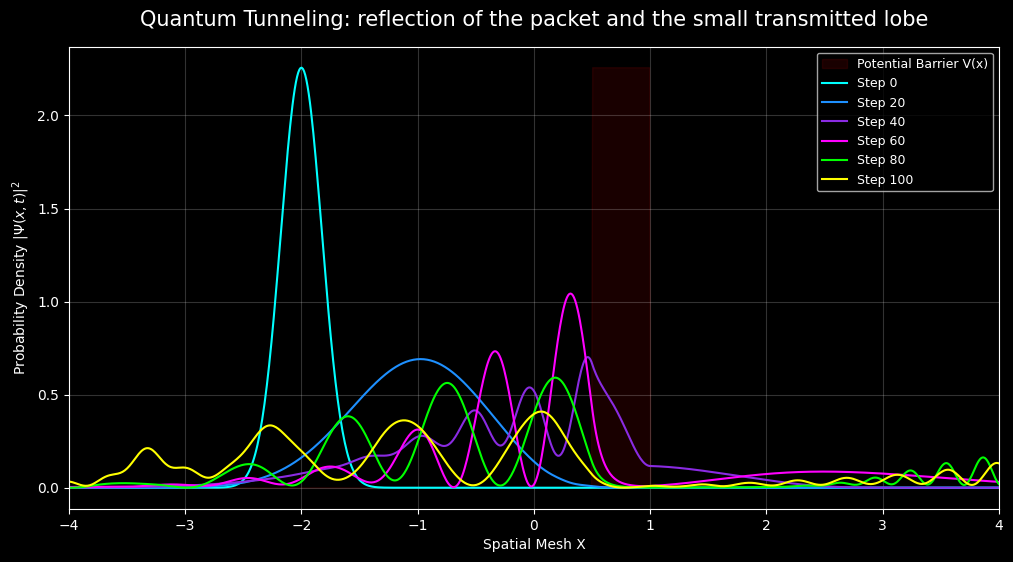

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.fill_between(x, V / np.max(V) * np.max(density_history[0]), color='red', alpha=0.1, label='Potential Barrier V(x)')

colors = ['cyan', 'dodgerblue', 'blueviolet', 'magenta', 'lime', 'yellow']

for i, p_dens in enumerate(density_history):
    ax.plot(x, p_dens, color=colors[i % len(colors)], label=f'Step {i*SNAP_EVERY}')

ax.set_title("Quantum Tunneling: reflection of the packet and the small transmitted lobe", fontsize=15, pad=15)
ax.set_xlabel("Spatial Mesh X")
ax.set_ylabel("Probability Density $|\\Psi(x,t)|^2$")
ax.set_xlim(-4, 4)
ax.legend(loc="upper right", fontsize=9)
plt.grid(alpha=0.2)
plt.show()